# Train Phase 2 Deep Model (Colab)

## 0. Configuration

In [1]:
from pathlib import Path

EPOCHS = 60
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
HIDDEN_DIMS = (128, 64)
BOTTLENECK = 32

MAX_TOTAL_ROWS = 1_200_000
MAX_BENIGN_FRACTION = 0.70
MAX_BENIGN_TRAIN_ROWS = 700_000
CHUNK_ROWS = 100_000
HELD_OUT_FAMILY = "Heartbleed"
SEED = 42

DRIVE_MY = Path('/content/drive/MyDrive')
CIC_CSV_FOLDER = 'cic_ids_data'

try:
    import google.colab  # noqa: F401
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False

## 0b. Mount Google Drive

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab, skipping Drive mount.')


Mounted at /content/drive


In [3]:
import sys
import subprocess
from pathlib import Path

if RUNNING_IN_COLAB:
    DATA_DIR = (DRIVE_MY / CIC_CSV_FOLDER).resolve()
    OUT_DIR = (DRIVE_MY / 'cic_ids_outputs' / 'phase2_dl').resolve()
else:
    base = Path.cwd().resolve()
    DATA_DIR = (base / 'data' / 'cic_ids').resolve()
    OUT_DIR = (base / 'models' / 'phase2_dl').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'numpy', 'pandas', 'scikit-learn', 'matplotlib', 'torch'
])
print('DATA_DIR =', DATA_DIR)
print('OUT_DIR  =', OUT_DIR)


DATA_DIR = /content/drive/MyDrive/cic_ids_data
OUT_DIR  = /content/drive/MyDrive/cic_ids_outputs/phase2_dl


## 1. Validate CSV files

In [4]:
CIC_DAY_FILES = (
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
)

if not DATA_DIR.is_dir():
    raise FileNotFoundError(f'Missing folder: {DATA_DIR}')
missing = [n for n in CIC_DAY_FILES if not (DATA_DIR / n).is_file()]
if missing:
    raise FileNotFoundError('Missing CSV files:\n- ' + '\n- '.join(missing))
print('All required CIC-IDS files found.')

All required CIC-IDS files found.


## 2. Load data with memory-safe chunking

In [5]:
import gc
import math
import numpy as np
import pandas as pd


def norm_family(label: str) -> str:
    s = str(label).strip().replace('\x00', '')
    low = s.lower()
    if low == 'benign': return 'Benign'
    if 'heartbleed' in low: return 'Heartbleed'
    if 'web attack' in low or 'webattack' in low: return 'WebAttack'
    if 'portscan' in low: return 'PortScan'
    if 'dos' in low and 'ddos' not in low: return 'DoS'
    if 'ddos' in low: return 'DDoS'
    if 'bot' in low: return 'Bot'
    if 'infiltration' in low: return 'Infiltration'
    return s

rng = np.random.default_rng(SEED)
target_total = int(MAX_TOTAL_ROWS) if MAX_TOTAL_ROWS else None
target_benign = None if target_total is None else int(target_total * MAX_BENIGN_FRACTION)
per_file_benign = None if target_benign is None else math.ceil(target_benign / len(CIC_DAY_FILES))

benign_parts, attack_parts = [], []
for name in CIC_DAY_FILES:
    p = DATA_DIR / name
    keep_b = keep_a = 0
    for chunk in pd.read_csv(p, low_memory=True, chunksize=CHUNK_ROWS):
        chunk.columns = [c.strip() for c in chunk.columns]
        raw = chunk['Label'].astype(str).str.strip()
        y = (raw.str.lower() != 'benign').astype(np.int8)
        fam = raw.map(norm_family)
        x = chunk.drop(columns=['Label'], errors='ignore').select_dtypes(include=[np.number])
        if x.empty:
            continue
        x = x.replace([np.inf, -np.inf], np.nan).astype(np.float32, copy=False)
        x['y'] = y.values
        x['attack_family'] = fam.values

        atk = x[x['y'] == 1]
        if len(atk):
            attack_parts.append(atk.copy())
            keep_a += len(atk)

        ben = x[x['y'] == 0]
        if len(ben):
            if per_file_benign is None:
                take = ben
            else:
                rem = per_file_benign - keep_b
                if rem <= 0:
                    take = None
                else:
                    n_take = min(rem, len(ben))
                    if n_take < len(ben):
                        idx = rng.choice(len(ben), size=n_take, replace=False)
                        take = ben.iloc[idx].copy()
                    else:
                        take = ben.copy()
            if take is not None and len(take):
                benign_parts.append(take)
                keep_b += len(take)

    print(f'loaded {name}: benign={keep_b:,}, attacks={keep_a:,}')
    gc.collect()

benign_df = pd.concat(benign_parts, ignore_index=True) if benign_parts else pd.DataFrame()
attack_df = pd.concat(attack_parts, ignore_index=True) if attack_parts else pd.DataFrame()
if target_total:
    if len(attack_df) >= target_total:
        clean = attack_df.sample(n=target_total, random_state=SEED).reset_index(drop=True)
    else:
        n_ben = max(0, target_total - len(attack_df))
        if len(benign_df) > n_ben:
            benign_df = benign_df.sample(n=n_ben, random_state=SEED).reset_index(drop=True)
        clean = pd.concat([benign_df, attack_df], ignore_index=True)
else:
    clean = pd.concat([benign_df, attack_df], ignore_index=True)

clean = clean.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
feature_cols = [c for c in clean.columns if c not in {'y', 'attack_family'}]
clean[feature_cols] = clean[feature_cols].fillna(clean[feature_cols].median(numeric_only=True))
print('loaded', len(clean), 'rows and', len(feature_cols), 'numeric features')
print(clean['attack_family'].value_counts().to_string())


loaded Monday-WorkingHours.pcap_ISCX.csv: benign=105,000, attacks=0
loaded Tuesday-WorkingHours.pcap_ISCX.csv: benign=105,000, attacks=13,835
loaded Wednesday-workingHours.pcap_ISCX.csv: benign=105,000, attacks=252,672
loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: benign=105,000, attacks=2,180
loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: benign=105,000, attacks=36
loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: benign=105,000, attacks=1,966
loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: benign=105,000, attacks=158,930
loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: benign=97,718, attacks=128,027
loaded 1200000 rows and 78 numeric features
attack_family
Benign          642354
DoS             252661
PortScan        158930
DDoS            128027
FTP-Patator       7938
SSH-Patator       5897
WebAttack         2180
Bot               1966
Infiltration        36
Heartbleed          11


## 3. Split + scale

In [6]:
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

@dataclass
class Split:
    x: pd.DataFrame
    y: np.ndarray

features = [c for c in clean.columns if c not in {'y', 'attack_family'}]
benign = clean[clean['y'] == 0]
attacks = clean[clean['y'] == 1]
held = attacks[attacks['attack_family'] == HELD_OUT_FAMILY]
known = attacks[attacks['attack_family'] != HELD_OUT_FAMILY]
if len(held) == 0 and len(attacks) > 0:
    HELD_OUT_FAMILY = attacks['attack_family'].value_counts().index[0]
    held = attacks[attacks['attack_family'] == HELD_OUT_FAMILY]
    known = attacks[attacks['attack_family'] != HELD_OUT_FAMILY]

b_tr, b_tmp = train_test_split(benign, test_size=0.30, random_state=SEED)
b_val, b_te = train_test_split(b_tmp, test_size=2/3, random_state=SEED)

te_known = pd.concat([b_te, known], ignore_index=True).sample(frac=1.0, random_state=SEED)
te_zero = pd.concat([b_te, held], ignore_index=True).sample(frac=1.0, random_state=SEED)

x_train = b_tr[features].to_numpy(dtype=np.float32)
x_val = b_val[features].to_numpy(dtype=np.float32)
if MAX_BENIGN_TRAIN_ROWS and len(x_train) > MAX_BENIGN_TRAIN_ROWS:
    idx = np.random.default_rng(SEED).choice(len(x_train), size=MAX_BENIGN_TRAIN_ROWS, replace=False)
    x_train = x_train[idx]

scaler = StandardScaler().fit(x_train)
x_train_s = scaler.transform(x_train).astype(np.float32)
x_val_s = scaler.transform(x_val).astype(np.float32)

x_known_s = scaler.transform(te_known[features].to_numpy(dtype=np.float32)).astype(np.float32)
y_known = te_known['y'].to_numpy(dtype=np.int8)
x_zero_s = scaler.transform(te_zero[features].to_numpy(dtype=np.float32)).astype(np.float32)
y_zero = te_zero['y'].to_numpy(dtype=np.int8)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, 'train shape:', x_train_s.shape, 'held-out family:', HELD_OUT_FAMILY)

device: cuda train shape: (449647, 78) held-out family: Heartbleed


## 4. Train, evaluate, diagnostics

In [7]:
import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

class Autoencoder(nn.Module):
    def __init__(self, n_features, hidden_dims=(128, 64), bottleneck_dim=32):
        super().__init__()
        enc, prev = [], n_features
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.ReLU(inplace=True)]
            prev = h
        enc += [nn.Linear(prev, bottleneck_dim), nn.ReLU(inplace=True)]
        self.encoder = nn.Sequential(*enc)
        dec, prev = [], bottleneck_dim
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev, h), nn.ReLU(inplace=True)]
            prev = h
        dec += [nn.Linear(prev, n_features)]
        self.decoder = nn.Sequential(*dec)
    def forward(self, x):
        return self.decoder(self.encoder(x))

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(x + self.net(x))

class ResidualDenoisingAE(nn.Module):
    def __init__(self, n_features, hidden_dims=(128, 64), bottleneck_dim=32, dropout=0.15):
        super().__init__()
        h1, h2 = hidden_dims
        self.enc_in = nn.Sequential(nn.Linear(n_features, h1), nn.BatchNorm1d(h1), nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.enc_res = ResidualBlock(h1, dropout=dropout)
        self.enc_mid = nn.Sequential(nn.Linear(h1, h2), nn.BatchNorm1d(h2), nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.bottleneck = nn.Linear(h2, bottleneck_dim)
        self.dec_in = nn.Sequential(nn.Linear(bottleneck_dim, h2), nn.BatchNorm1d(h2), nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.dec_mid = nn.Sequential(nn.Linear(h2, h1), nn.BatchNorm1d(h1), nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.dec_res = ResidualBlock(h1, dropout=dropout)
        self.out = nn.Linear(h1, n_features)
    def forward(self, x):
        x = self.enc_in(x)
        x = self.enc_res(x)
        x = self.enc_mid(x)
        z = self.bottleneck(x)
        x = self.dec_in(z)
        x = self.dec_mid(x)
        x = self.dec_res(x)
        return self.out(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_loaders(x_train_np, x_val_np, batch_size):
    num_workers = 2
    pin_memory = torch.cuda.is_available()
    common = {'batch_size': batch_size, 'num_workers': num_workers, 'pin_memory': pin_memory}
    if num_workers > 0:
        common['persistent_workers'] = True
        common['prefetch_factor'] = 2
    tr_loader = DataLoader(TensorDataset(torch.from_numpy(x_train_np)), shuffle=True, **common)
    va_loader = DataLoader(TensorDataset(torch.from_numpy(x_val_np)), shuffle=False, **common)
    return tr_loader, va_loader

@torch.no_grad()
def reconstruction_error(model, x_np, device, bs=2048):
    x_np = np.ascontiguousarray(x_np, dtype=np.float32)
    out = np.empty(x_np.shape[0], dtype=np.float32)
    model.eval()
    for i in range(0, len(x_np), bs):
        xb = torch.from_numpy(x_np[i:i+bs]).to(device, non_blocking=True)
        rr = model(xb)
        out[i:i+len(xb)] = ((rr - xb) ** 2).mean(dim=1).cpu().numpy()
    return out


def choose_threshold_balanced(benign_scores, attack_scores):
    rng = np.random.default_rng(SEED)
    n = max(len(benign_scores), len(attack_scores))
    b = rng.choice(benign_scores, size=n, replace=(len(benign_scores) < n))
    a = rng.choice(attack_scores, size=n, replace=(len(attack_scores) < n))
    y = np.concatenate([np.zeros(n, dtype=np.int8), np.ones(n, dtype=np.int8)])
    s = np.concatenate([b, a])
    lo, hi = np.percentile(s, 1), np.percentile(s, 99)
    grid = np.linspace(lo, hi, 200)
    best_thr, best_f1 = float(np.quantile(benign_scores, 0.99)), -1.0
    for t in grid:
        pred = (s >= t).astype(np.int8)
        f1 = f1_score(y, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = float(f1), float(t)
    return best_thr, best_f1


def metrics_from_scores(y_true, scores, thr):
    pred = (scores >= thr).astype(np.int8)
    return {
        'roc_auc': float(roc_auc_score(y_true, scores)),
        'precision': float(precision_score(y_true, pred, zero_division=0)),
        'recall': float(recall_score(y_true, pred, zero_division=0)),
        'f1': float(f1_score(y_true, pred, zero_division=0)),
    }, pred


def train_autoencoder_model(model, x_train_np, x_val_np, *, epochs=40, lr=1e-3, weight_decay=1e-5, noise_std=0.01, patience=8):
    tr_loader, va_loader = make_loaders(x_train_np, x_val_np, BATCH_SIZE)
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(epochs, 1), eta_min=lr * 0.1)
    loss_fn = nn.MSELoss()
    history = {'train_loss': [], 'val_loss': []}
    best = {'val': float('inf'), 'epoch': 0, 'state': None}
    no_improve = 0
    t0 = time.perf_counter()
    for ep in range(1, epochs + 1):
        model.train()
        tr_tot = tr_n = 0
        for (xb,) in tr_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            noisy = xb + noise_std * torch.randn_like(xb)
            rec = model(noisy)
            loss = loss_fn(rec, xb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()
            tr_tot += float(loss.detach()) * xb.size(0)
            tr_n += xb.size(0)
        model.eval()
        va_tot = va_n = 0
        with torch.no_grad():
            for (xb,) in va_loader:
                xb = xb.to(DEVICE, non_blocking=True)
                rec = model(xb)
                loss = loss_fn(rec, xb)
                va_tot += float(loss.detach()) * xb.size(0)
                va_n += xb.size(0)
        tr = tr_tot / max(tr_n, 1)
        va = va_tot / max(va_n, 1)
        history['train_loss'].append(tr)
        history['val_loss'].append(va)
        scheduler.step()
        print(f"[{model.__class__.__name__}] epoch {ep:03d}/{epochs} train={tr:.6f} val={va:.6f}")
        if va < best['val'] - 1e-7:
            best['val'] = va
            best['epoch'] = ep
            best['state'] = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[{model.__class__.__name__}] early stop at epoch {ep}")
                break
    if best['state'] is not None:
        model.load_state_dict(best['state'])
    elapsed = time.perf_counter() - t0
    return model, history, best, elapsed

val_attack_sample = known.sample(n=min(len(known), max(2000, len(b_val) // 6)), random_state=SEED)
val_mix = pd.concat([b_val, val_attack_sample], ignore_index=True).sample(frac=1.0, random_state=SEED)
x_val_mix_s = scaler.transform(val_mix[features].to_numpy(dtype=np.float32)).astype(np.float32)
y_val_mix = val_mix['y'].to_numpy(dtype=np.int8)
x_val_ben_s = scaler.transform(b_val[features].to_numpy(dtype=np.float32)).astype(np.float32)

abl_epochs = min(EPOCHS, 40)

baseline_model = Autoencoder(x_train_s.shape[1], HIDDEN_DIMS, BOTTLENECK)
baseline_model, hist_base, best_base, sec_base = train_autoencoder_model(
    baseline_model, x_train_s, x_val_s, epochs=abl_epochs, lr=LEARNING_RATE, weight_decay=1e-5, noise_std=0.0, patience=8
)

special_model = ResidualDenoisingAE(x_train_s.shape[1], HIDDEN_DIMS, BOTTLENECK, dropout=0.15)
special_model, hist_spec, best_spec, sec_spec = train_autoencoder_model(
    special_model, x_train_s, x_val_s, epochs=abl_epochs, lr=LEARNING_RATE, weight_decay=2e-5, noise_std=0.02, patience=8
)

val_ben_base = reconstruction_error(baseline_model, x_val_ben_s, DEVICE)
val_mix_base = reconstruction_error(baseline_model, x_val_mix_s, DEVICE)
val_att_base = val_mix_base[y_val_mix == 1]
thr_base, f1_bal_base = choose_threshold_balanced(val_ben_base, val_att_base)

val_ben_spec = reconstruction_error(special_model, x_val_ben_s, DEVICE)
val_mix_spec = reconstruction_error(special_model, x_val_mix_s, DEVICE)
val_att_spec = val_mix_spec[y_val_mix == 1]
thr_spec, f1_bal_spec = choose_threshold_balanced(val_ben_spec, val_att_spec)

known_base = reconstruction_error(baseline_model, x_known_s, DEVICE)
zero_base = reconstruction_error(baseline_model, x_zero_s, DEVICE)
known_spec = reconstruction_error(special_model, x_known_s, DEVICE)
zero_spec = reconstruction_error(special_model, x_zero_s, DEVICE)

m_known_base, pred_known_base = metrics_from_scores(y_known, known_base, thr_base)
m_zero_base, pred_zero_base = metrics_from_scores(y_zero, zero_base, thr_base)
m_known_spec, pred_known_spec = metrics_from_scores(y_known, known_spec, thr_spec)
m_zero_spec, pred_zero_spec = metrics_from_scores(y_zero, zero_spec, thr_spec)

trivial_known_scores = np.abs(x_known_s[:, 0])
trivial_zero_scores = np.abs(x_zero_s[:, 0])
trivial_thr = float(np.quantile(np.abs(x_val_ben_s[:, 0]), 0.99))
m_known_triv, pred_known_triv = metrics_from_scores(y_known, trivial_known_scores, trivial_thr)
m_zero_triv, pred_zero_triv = metrics_from_scores(y_zero, trivial_zero_scores, trivial_thr)

ablation_results = {
    'BaselineAE': {
        'params': int(count_params(baseline_model)),
        'train_seconds': float(sec_base),
        'best_epoch': int(best_base['epoch']),
        'best_val_loss': float(best_base['val']),
        'threshold': float(thr_base),
        'balanced_val_f1': float(f1_bal_base),
        'known': m_known_base,
        'zero_day': m_zero_base,
    },
    'ResidualDenoisingAE': {
        'params': int(count_params(special_model)),
        'train_seconds': float(sec_spec),
        'best_epoch': int(best_spec['epoch']),
        'best_val_loss': float(best_spec['val']),
        'threshold': float(thr_spec),
        'balanced_val_f1': float(f1_bal_spec),
        'known': m_known_spec,
        'zero_day': m_zero_spec,
    },
    'TrivialAbsZFeature0': {
        'threshold': float(trivial_thr),
        'known': m_known_triv,
        'zero_day': m_zero_triv,
    },
}

print('=== Architecture / baseline comparison ===')
for name, d in ablation_results.items():
    print('')
    print(name)
    if 'params' in d:
        print(f"  params={d['params']:,} train_seconds={d['train_seconds']:.1f} best_epoch={d['best_epoch']} best_val={d['best_val_loss']:.6f}")
        print(f"  threshold={d['threshold']:.6f} balanced_val_f1={d['balanced_val_f1']:.4f}")
    print(f"  known    AUC={d['known']['roc_auc']:.4f} P={d['known']['precision']:.4f} R={d['known']['recall']:.4f} F1={d['known']['f1']:.4f}")
    print(f"  zero-day AUC={d['zero_day']['roc_auc']:.4f} P={d['zero_day']['precision']:.4f} R={d['zero_day']['recall']:.4f} F1={d['zero_day']['f1']:.4f}")

best_model_name = max(['BaselineAE', 'ResidualDenoisingAE'], key=lambda n: (ablation_results[n]['known']['f1'], ablation_results[n]['known']['roc_auc']))
best_model = baseline_model if best_model_name == 'BaselineAE' else special_model
best_hist = hist_base if best_model_name == 'BaselineAE' else hist_spec
best_thr = thr_base if best_model_name == 'BaselineAE' else thr_spec
best_known_scores = known_base if best_model_name == 'BaselineAE' else known_spec
best_zero_scores = zero_base if best_model_name == 'BaselineAE' else zero_spec
best_pred_known = pred_known_base if best_model_name == 'BaselineAE' else pred_known_spec
best_pred_zero = pred_zero_base if best_model_name == 'BaselineAE' else pred_zero_spec

print('')
print(f"Selected deployment candidate: {best_model_name}")

cm_known = confusion_matrix(y_known, best_pred_known)
cm_zero = confusion_matrix(y_zero, best_pred_zero)

known_eval = te_known[['attack_family', 'y']].copy().reset_index(drop=True)
known_eval['score'] = best_known_scores
known_eval['pred'] = best_pred_known

family_rows = []
for fam, g in known_eval.groupby('attack_family'):
    y_f = g['y'].to_numpy(dtype=np.int8)
    p_f = g['pred'].to_numpy(dtype=np.int8)
    auc_f = np.nan
    if len(np.unique(y_f)) > 1:
        auc_f = roc_auc_score(y_f, g['score'].to_numpy(dtype=np.float32))
    family_rows.append({
        'family': fam,
        'support': int(len(g)),
        'precision': float(precision_score(y_f, p_f, zero_division=0)),
        'recall': float(recall_score(y_f, p_f, zero_division=0)),
        'f1': float(f1_score(y_f, p_f, zero_division=0)),
        'auc_if_defined': float(auc_f) if not np.isnan(auc_f) else np.nan,
    })

family_df = pd.DataFrame(family_rows).sort_values(['f1', 'support'], ascending=[True, False]).reset_index(drop=True)
print('')
print('Per-family diagnostic table:')
print(family_df.to_string(index=False))

rng = np.random.default_rng(SEED)

def stress_test(scores_fn_model, x_np, y_np, *, noise_std=0.02, drop_prob=0.10):
    x_noise = x_np + noise_std * rng.normal(size=x_np.shape).astype(np.float32)
    mask = rng.uniform(size=x_np.shape) > drop_prob
    x_drop = (x_np * mask.astype(np.float32)).astype(np.float32)
    s_noise = scores_fn_model(x_noise)
    s_drop = scores_fn_model(x_drop)
    m_noise, _ = metrics_from_scores(y_np, s_noise, best_thr)
    m_drop, _ = metrics_from_scores(y_np, s_drop, best_thr)
    return m_noise, m_drop

scores_fn = lambda x: reconstruction_error(best_model, x, DEVICE)
rob_known_noise, rob_known_drop = stress_test(scores_fn, x_known_s, y_known, noise_std=0.02, drop_prob=0.10)
rob_zero_noise, rob_zero_drop = stress_test(scores_fn, x_zero_s, y_zero, noise_std=0.02, drop_prob=0.10)
robustness_results = {
    'known_noise': rob_known_noise,
    'known_feature_dropout': rob_known_drop,
    'zero_noise': rob_zero_noise,
    'zero_feature_dropout': rob_zero_drop,
}

print('')
print('Robustness stress-test metrics:')
for k, v in robustness_results.items():
    print(f"{k:>22} | AUC={v['roc_auc']:.4f} P={v['precision']:.4f} R={v['recall']:.4f} F1={v['f1']:.4f}")



[Autoencoder] epoch 001/40 train=0.204116 val=0.127195
[Autoencoder] epoch 002/40 train=0.105427 val=0.108718
[Autoencoder] epoch 003/40 train=0.079771 val=0.081620
[Autoencoder] epoch 004/40 train=0.068536 val=0.151250
[Autoencoder] epoch 005/40 train=0.067915 val=0.084852
[Autoencoder] epoch 006/40 train=0.059117 val=0.061857
[Autoencoder] epoch 007/40 train=0.065100 val=0.036071
[Autoencoder] epoch 008/40 train=0.056407 val=0.036615
[Autoencoder] epoch 009/40 train=0.043960 val=0.081406
[Autoencoder] epoch 010/40 train=0.054478 val=0.037202
[Autoencoder] epoch 011/40 train=0.028739 val=0.047360
[Autoencoder] epoch 012/40 train=0.039758 val=0.041227
[Autoencoder] epoch 013/40 train=0.033236 val=0.035086
[Autoencoder] epoch 014/40 train=0.028056 val=0.054398
[Autoencoder] epoch 015/40 train=0.036224 val=0.022654
[Autoencoder] epoch 016/40 train=0.021598 val=0.021419
[Autoencoder] epoch 017/40 train=0.019159 val=0.029346
[Autoencoder] epoch 018/40 train=0.016217 val=0.037233
[Autoencod

## 5. Plots and save artifacts

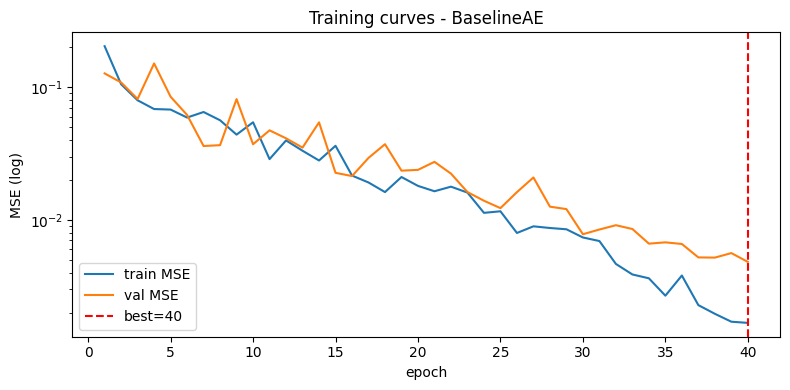

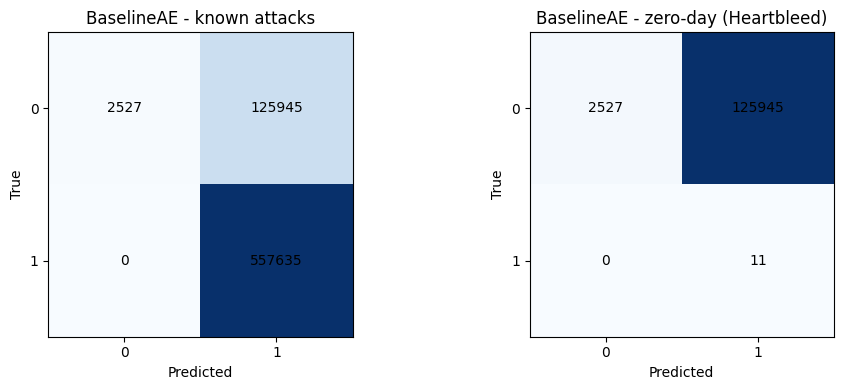

Saved model: /content/drive/MyDrive/cic_ids_outputs/phase2_dl/ft_ae_level7.pth
Saved summary: /content/drive/MyDrive/cic_ids_outputs/phase2_dl/level7_results.json
Saved history: /content/drive/MyDrive/cic_ids_outputs/phase2_dl/history_level7.json


In [8]:
import matplotlib.pyplot as plt
import json

ep = np.arange(1, len(best_hist['train_loss']) + 1)
plt.figure(figsize=(8, 4))
plt.plot(ep, best_hist['train_loss'], label='train MSE')
plt.plot(ep, best_hist['val_loss'], label='val MSE')
best_epoch_vis = int(np.argmin(best_hist['val_loss']) + 1)
plt.axvline(best_epoch_vis, color='red', linestyle='--', label=f'best={best_epoch_vis}')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE (log)')
plt.title(f'Training curves - {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in [
    (axes[0], cm_known, f'{best_model_name} - known attacks'),
    (axes[1], cm_zero, f'{best_model_name} - zero-day ({HELD_OUT_FAMILY})'),
]:
    ax.imshow(cm, cmap='Blues')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
plt.tight_layout()
plt.show()

ckpt = OUT_DIR / 'ft_ae_level7.pth'
torch.save({
    'selected_model': best_model_name,
    'config': {
        'n_features': int(x_train_s.shape[1]),
        'hidden_dims': list(HIDDEN_DIMS),
        'bottleneck_dim': int(BOTTLENECK),
    },
    'state_dict': best_model.state_dict(),
    'scaler': {
        'mean': np.asarray(scaler.mean_, dtype=np.float32),
        'scale': np.asarray(scaler.scale_, dtype=np.float32),
    },
    'threshold': float(best_thr),
    'feature_names': list(features),
    'extra': {
        'held_out_family': HELD_OUT_FAMILY,
        'epochs_run': int(len(best_hist['train_loss'])),
        'best_epoch': int(best_epoch_vis),
    },
}, str(ckpt))

summary = {
    'selected_model': best_model_name,
    'ablation_results': ablation_results,
    'robustness_results': robustness_results,
    'per_family_known': family_df.to_dict(orient='records'),
    'threshold': float(best_thr),
    'best_epoch': int(best_epoch_vis),
}
(OUT_DIR / 'level7_results.json').write_text(json.dumps(summary, indent=2))
(OUT_DIR / 'history_level7.json').write_text(json.dumps({
    'train_loss': best_hist['train_loss'],
    'val_loss': best_hist['val_loss'],
    'best_epoch': int(best_epoch_vis),
    'threshold': float(best_thr),
    'selected_model': best_model_name,
}, indent=2))

print('Saved model:', ckpt)
print('Saved summary:', OUT_DIR / 'level7_results.json')
print('Saved history:', OUT_DIR / 'history_level7.json')

